## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('/Users/legiabao/Downloads/practice/w4/shopping_trends (1).csv')

In [3]:
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [9]:
df.columns.to_list()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Payment Method',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Preferred Payment Method',
 'Frequency of Purchases']

In [5]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [10]:
# TODO: drop the Customer ID column  
df.drop(columns='Customer ID')

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [11]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [12]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [13]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [15]:
# TODO: univariate — describe numeric columns
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [16]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

In [21]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly


In [23]:
df['Category'].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [25]:
df[['Gender', 'Age', 'Category', 'Size']]

,Gender,Age,Category,Size
0,Male,55,Clothing,L
1,Male,19,Clothing,L
2,Male,50,Clothing,S
3,Male,21,Footwear,M
4,Male,45,Clothing,M
...,...,...,...,...
3895,Female,40,Clothing,L
3896,Female,52,Accessories,L
3897,Female,46,Accessories,L
3898,Female,44,Footwear,S


## **EDA**

### **Item Purchased**

In [27]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
top_item = df['Item Purchased'].value_counts().reset_index()
top_item.columns = ['Item Purchased', 'count']

top_item_m = male_df['Item Purchased'].value_counts().reset_index()
top_item_m.columns = ['Item Purchased', 'count']

top_item_f = female_df['Item Purchased'].value_counts().reset_index()
top_item_f.columns = ['Item Purchased', 'count']

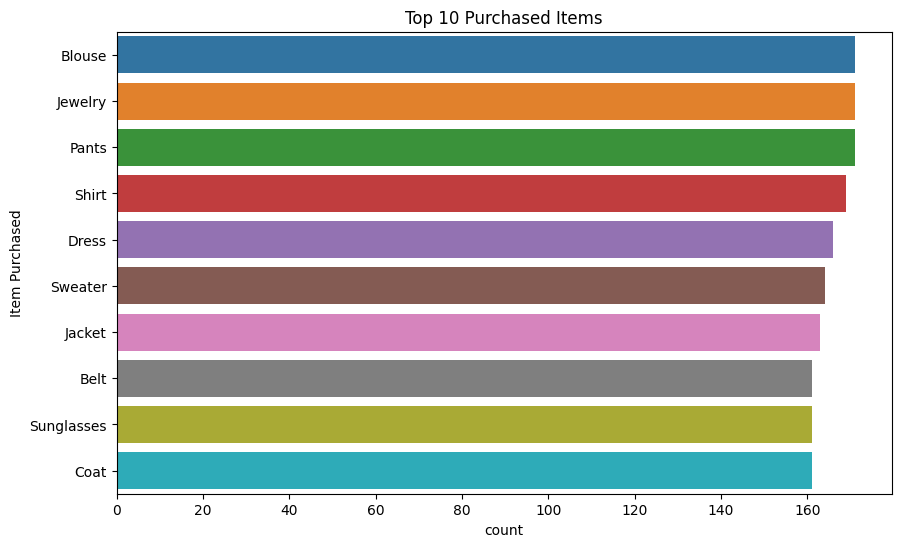

In [28]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

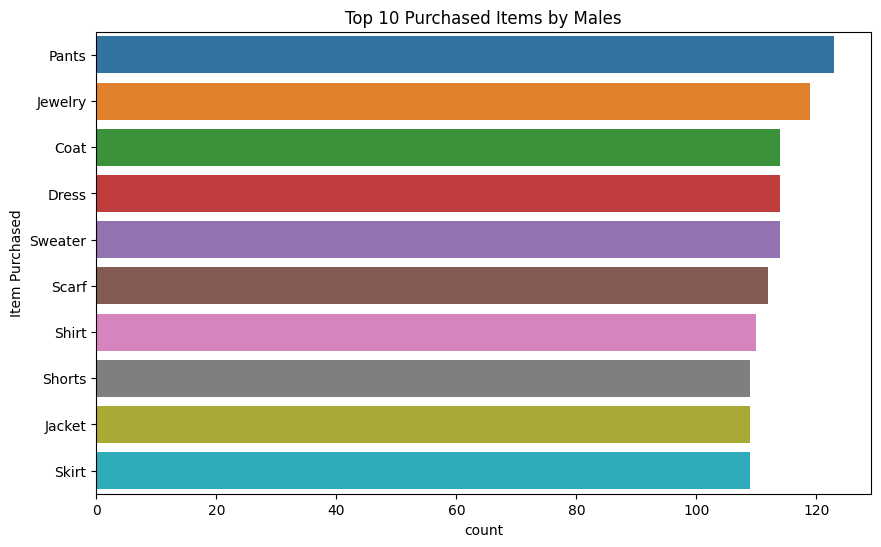

In [29]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_m.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

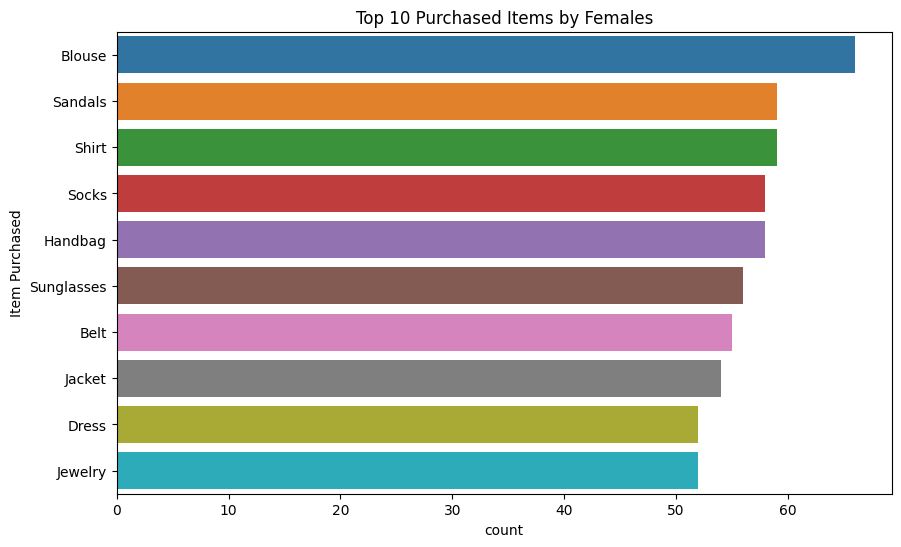

In [30]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [32]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [34]:
# TODO: count Size with value_counts() for male_df and female_df
male_df['Size'].value_counts()
female_df['Size'].value_counts()

Male:
Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

Female:
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [50]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg.columns = ['Category', 'count']
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [51]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
pd.concat(
    [
        male_df['Category'].value_counts().rename('Male'),
        female_df['Category'].value_counts().rename('Female')
    ],
    axis=1
).fillna(0).astype(int)

,Male,Female
Category,,
Clothing,1181,556
Accessories,848,392
Footwear,400,199
Outerwear,223,101


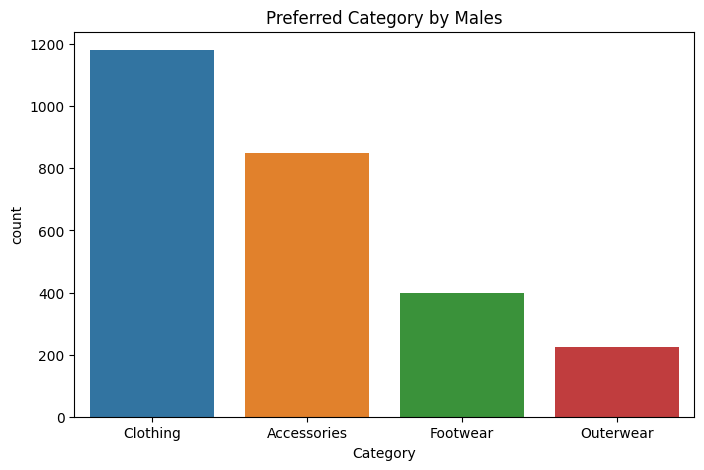

In [52]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=male_df['Category'].value_counts().rename_axis('Category').reset_index(name='count'),
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

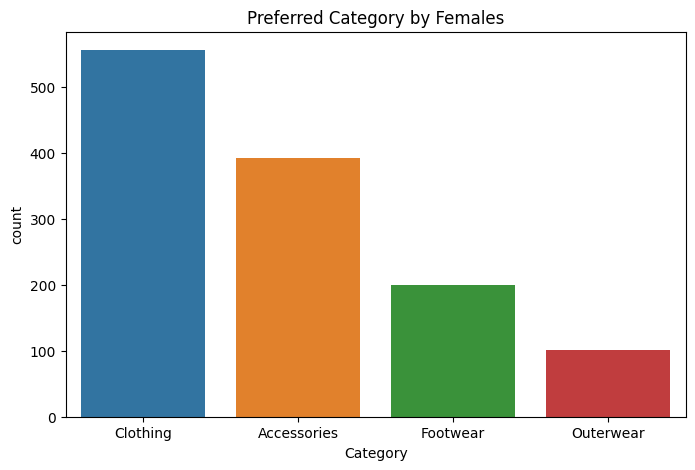

In [53]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=female_df['Category'].value_counts().rename_axis('Category').reset_index(name='count'),
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

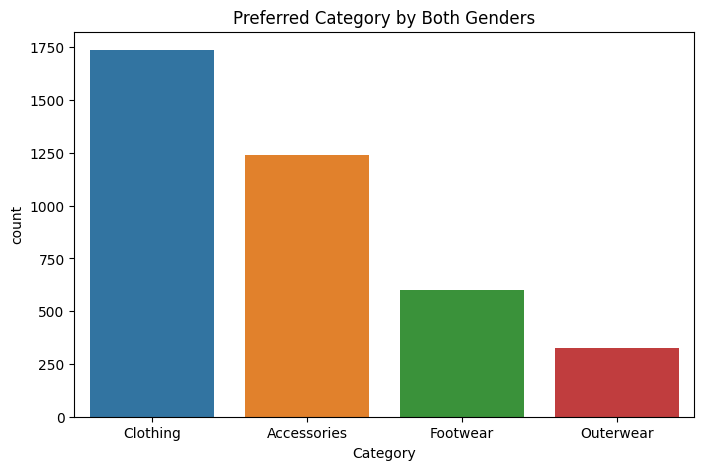

In [54]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Both Genders")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

In [55]:
# TODO: show Category counts for males and females
pd.concat(
    [
        male_df['Category'].value_counts().rename('Male'),
        female_df['Category'].value_counts().rename('Female')
    ],
    axis=1
).fillna(0).astype(int)

,Male,Female
Category,,
Clothing,1181,556
Accessories,848,392
Footwear,400,199
Outerwear,223,101


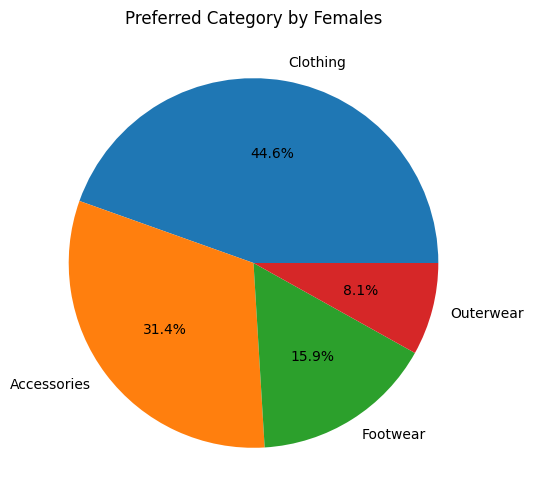

In [56]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    female_df['Category'].value_counts(),
    labels=female_df['Category'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

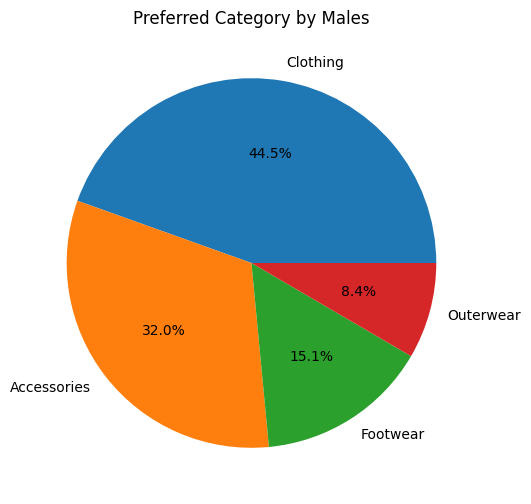

In [57]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    male_df['Category'].value_counts(),
    labels=male_df['Category'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show()

### **Review ratings**

In [64]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()
avg_cr_f

np.float64(3.7044964028776977)

In [65]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
avg_cr_m

np.float64(3.7319220999153258)

In [66]:
avg_cr_m, avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

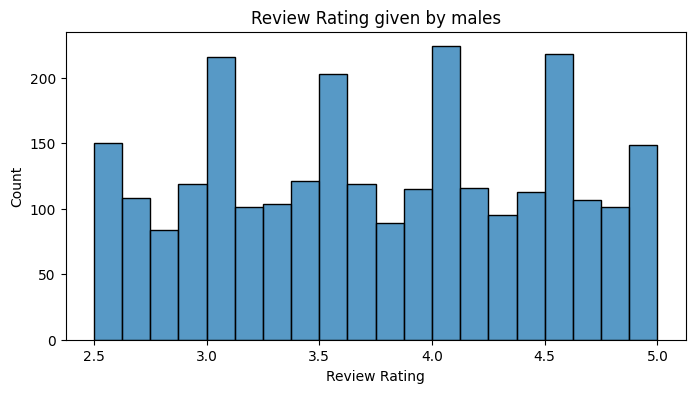

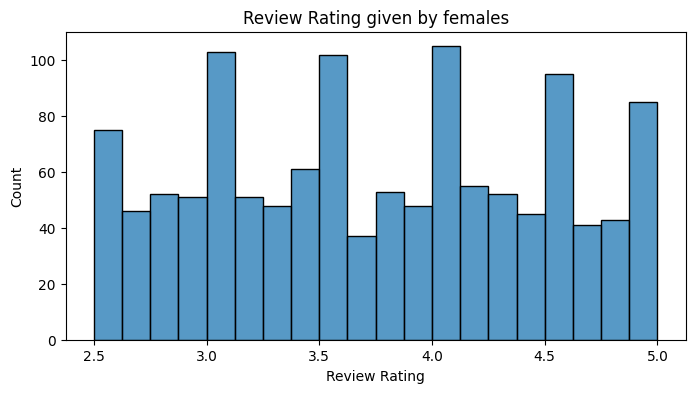

In [67]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [68]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts().sort_index()

Review Rating
2.5    17
2.6    45
2.7    55
2.8    41
2.9    55
3.0    49
3.1    46
3.2    41
3.3    49
3.4    59
3.5    48
3.6    46
3.7    61
3.8    39
3.9    52
4.0    52
4.1    48
4.2    52
4.3    45
4.4    43
4.5    36
4.6    46
4.7    46
4.8    46
4.9    48
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [69]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

m_tpa, f_tpa

(np.int64(157890), np.int64(75191))

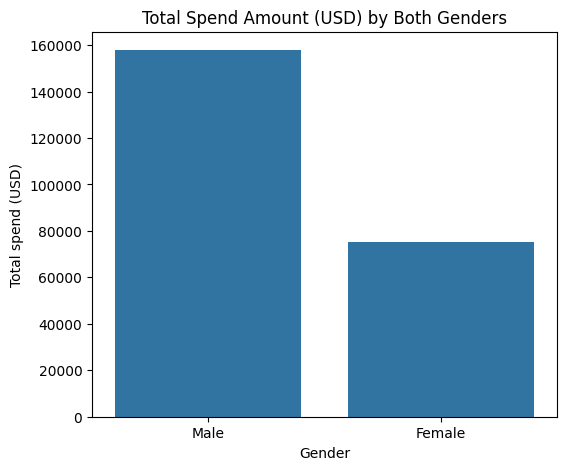

In [70]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    x=['Male', 'Female'],
    y=[m_tpa, f_tpa]
)
plt.title("Total Spend Amount (USD) by Both Genders")
plt.xlabel('Gender')
plt.ylabel('Total spend (USD)')
plt.show()

In [71]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

cc_f, ca_f, cf_f, co_f

(      Customer ID  Age  Gender Item Purchased  Category  \
 2652         2653   23  Female         Shorts  Clothing   
 2653         2654   67  Female         Blouse  Clothing   
 2656         2657   52  Female         Shorts  Clothing   
 2657         2658   52  Female          Dress  Clothing   
 2660         2661   24  Female          Pants  Clothing   
 ...           ...  ...     ...            ...       ...   
 3889         3890   57  Female          Dress  Clothing   
 3890         3891   35  Female          Shirt  Clothing   
 3891         3892   36  Female          Dress  Clothing   
 3894         3895   66  Female          Skirt  Clothing   
 3895         3896   40  Female         Hoodie  Clothing   
 
       Purchase Amount (USD)        Location Size      Color  Season  \
 2652                     20        Maryland    L       Cyan  Summer   
 2653                     36       Wisconsin    L   Lavender    Fall   
 2656                     76         Indiana    L     Yellow  

In [72]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

cc_m, ca_m, cf_m, co_m

(      Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
 0               1   55   Male         Blouse  Clothing                     53   
 1               2   19   Male        Sweater  Clothing                     64   
 2               3   50   Male          Jeans  Clothing                     73   
 4               5   45   Male         Blouse  Clothing                     49   
 6               7   63   Male          Shirt  Clothing                     85   
 ...           ...  ...    ...            ...       ...                    ...   
 2640         2641   30   Male          Skirt  Clothing                     75   
 2644         2645   25   Male          Pants  Clothing                     83   
 2646         2647   33   Male        T-shirt  Clothing                     56   
 2648         2649   51   Male          Pants  Clothing                     84   
 2650         2651   20   Male          Socks  Clothing                     35   
 
            Lo

In [73]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
pcu

{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

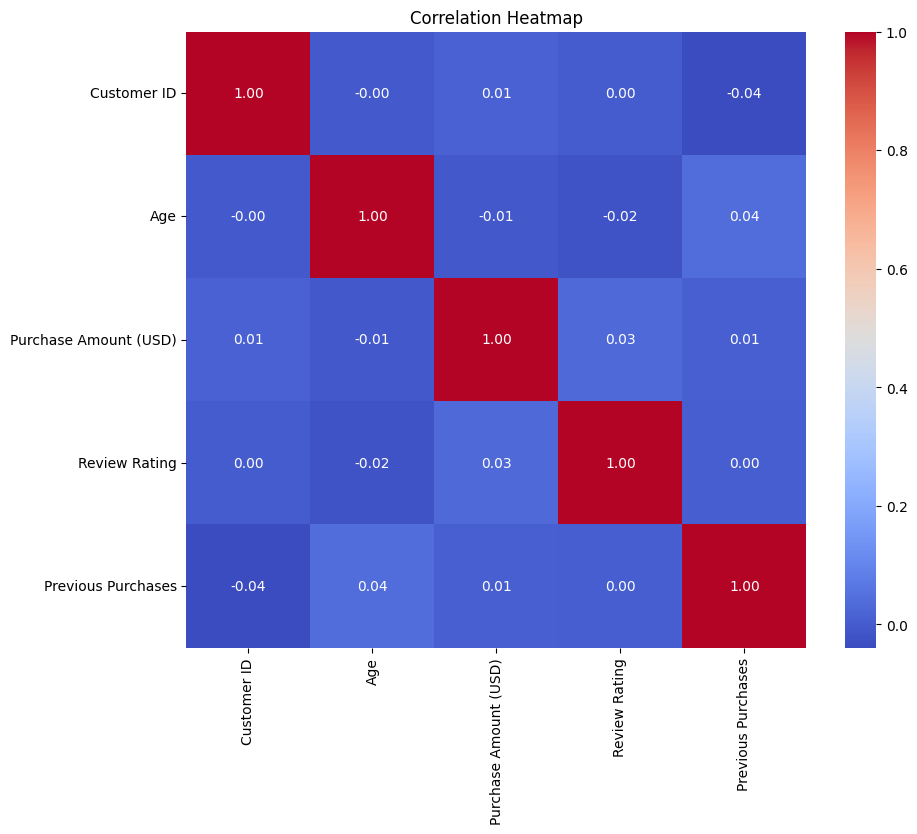

In [74]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [75]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Customer ID,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,1,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,...,0,1,1,0,0,0,0,1,0,0
1,2,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,...,0,1,1,0,0,0,0,1,0,0
2,3,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,...,0,1,0,0,1,0,0,1,0,0
3,4,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,...,0,1,0,1,0,0,0,0,1,0
4,5,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,...,0,1,0,1,0,0,0,1,0,0


In [76]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']]).ravel()
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']]).ravel()
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [77]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[0, 50, 75, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
df['Amount_bin'].value_counts()

Amount_bin
Low       1514
High      1214
Medium    1172
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.